# 01. Data Understanding

**เป้าหมายของขั้นนี้**
- เข้าใจโครงสร้างข้อมูล
- ระบุ Target ที่เหมาะสม
- ดูปัญหาเบื้องต้น (missing, imbalance, noise)
- ตั้งสมมติฐานเบื้องต้นสำหรับ EDA และ Feature Engineering

**คำถามสำคัญที่ต้องตอบให้ได้ในขั้นนี้**
1. เราจะทำนายอะไร? (Target)
2. Class มีกี่คลาส และสมดุลไหม?
3. Feature ไหนน่าจะมีประโยชน์ / ไม่มีประโยชน์?
4. มีปัญหา data quality อะไรบ้าง?

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('Libraries loaded successfully')

Libraries loaded successfully


## 1.1 โหลดข้อมูลและดูภาพรวม

In [73]:
df = pd.read_excel('../data/raw/disaster_prediction_dataset.xlsx')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Shape: 17,756 rows × 47 columns


In [74]:
df.head()

,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,Country,Subregion,Region,Location,Origin,Associated Types,OFDA/BHA Response,Appeal,Declaration,AID Contribution ('000 US$),Magnitude,Magnitude Scale,Latitude,Longitude,River Basin,Start Year,Start Month,Start Day,End Year,End Month,End Day,Total Deaths,No. Injured,No. Affected,No. Homeless,Total Affected,Reconstruction Costs ('000 US$),"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,GADM Admin Units,Entry Date,Last Update
0,1900-0003-USA,Yes,nat-met-sto-tro,Natural,Meteorological,Storm,Tropical cyclone,NaN,NaN,USA,United States of America,Northern America,Americas,Galveston (Texas),NaN,"Avalanche (Snow, Debris)",No,No,No,NaN,220.0,Kph,NaN,NaN,NaN,1900,9.0,8.0,1900,9.0,8.0,6000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30000.0,1131126.0,2.652223,NaN,NaN,2004-10-18,2023-10-17
1,1900-0006-JAM,Yes,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,JAM,Jamaica,Latin America and the Caribbean,Americas,Saint James,NaN,NaN,No,No,No,NaN,NaN,Km2,NaN,NaN,NaN,1900,1.0,6.0,1900,1.0,6.0,300.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.652223,NaN,NaN,2003-07-01,2023-09-25
2,1900-0007-JAM,Yes,nat-bio-epi-vir,Natural,Biological,Epidemic,Viral disease,NaN,Gastroenteritis,JAM,Jamaica,Latin America and the Caribbean,Americas,Porus,NaN,NaN,No,No,No,NaN,NaN,Vaccinated,NaN,NaN,NaN,1900,1.0,13.0,1900,1.0,13.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.652223,NaN,NaN,2003-07-01,2023-09-25
3,1900-0008-JPN,Yes,nat-geo-vol-ash,Natural,Geophysical,Volcanic activity,Ash fall,NaN,NaN,JPN,Japan,Eastern Asia,Asia,NaN,NaN,NaN,No,No,No,NaN,NaN,NaN,NaN,NaN,NaN,1900,7.0,7.0,1900,7.0,7.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.652223,NaN,NaN,2003-07-01,2023-09-25
4,1900-0009-TUR,Yes,nat-geo-ear-gro,Natural,Geophysical,Earthquake,Ground movement,NaN,NaN,TUR,Türkiye,Western Asia,Asia,"KARS,KARAKURT,KAGIZMAN,DIGOR",NaN,NaN,No,No,No,NaN,5.9,Moment Magnitude,40.3,43.1,NaN,1900,7.0,12.0,1900,7.0,12.0,140.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.652223,NaN,NaN,2019-08-05,2023-09-25


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17756 entries, 0 to 17755
Data columns (total 47 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   DisNo.                                     17756 non-null  object 
 1   Historic                                   17756 non-null  object 
 2   Classification Key                         17756 non-null  object 
 3   Disaster Group                             17756 non-null  object 
 4   Disaster Subgroup                          17756 non-null  object 
 5   Disaster Type                              17756 non-null  object 
 6   Disaster Subtype                           17756 non-null  object 
 7   External IDs                               4594 non-null   object 
 8   Event Name                                 4319 non-null   object 
 9   ISO                                        17756 non-null  object 
 10  Country               

## 1.2 ดูรายชื่อคอลัมน์ทั้งหมด + ความหมายเบื้องต้น

ลองแบ่งกลุ่มคอลัมน์ตามประเภท:

In [76]:
print('=== รายชื่อคอลัมน์ทั้งหมด ===')
for i, col in enumerate(df.columns):
    print(f'{i:2d}. {col}')

=== รายชื่อคอลัมน์ทั้งหมด ===
 0. DisNo.
 1. Historic
 2. Classification Key
 3. Disaster Group
 4. Disaster Subgroup
 5. Disaster Type
 6. Disaster Subtype
 7. External IDs
 8. Event Name
 9. ISO
10. Country
11. Subregion
12. Region
13. Location
14. Origin
15. Associated Types
16. OFDA/BHA Response
17. Appeal
18. Declaration
19. AID Contribution ('000 US$)
20. Magnitude
21. Magnitude Scale
22. Latitude
23. Longitude
24. River Basin
25. Start Year
26. Start Month
27. Start Day
28. End Year
29. End Month
30. End Day
31. Total Deaths
32. No. Injured
33. No. Affected
34. No. Homeless
35. Total Affected
36. Reconstruction Costs ('000 US$)
37. Reconstruction Costs, Adjusted ('000 US$)
38. Insured Damage ('000 US$)
39. Insured Damage, Adjusted ('000 US$)
40. Total Damage ('000 US$)
41. Total Damage, Adjusted ('000 US$)
42. CPI
43. Admin Units
44. GADM Admin Units
45. Entry Date
46. Last Update


**การแบ่งกลุ่มคอลัมน์ (ลองวิเคราะห์เองก่อน):**

| กลุ่ม | คอลัมน์ | หมายเหตุ |
|-------|---------|----------|
| **Identifier** | DisNo., Classification Key, External IDs, Event Name | มักไม่ใช้เป็น feature |
| **Target candidates** | Disaster Group, Disaster Subgroup, Disaster Type, Disaster Subtype | ต้องเลือก 1 ตัว |
| **Location** | ISO, Country, Subregion, Region, Location, Latitude, Longitude, River Basin, Admin Units, GADM Admin Units | |
| **Time** | Start Year/Month/Day, End Year/Month/Day, Entry Date, Last Update | |
| **Impact / Damage** | Total Deaths, No. Injured, No. Affected, No. Homeless, Total Affected, Reconstruction Costs..., Insured Damage..., Total Damage..., AID Contribution | missing สูงมากบางตัว |
| **Magnitude** | Magnitude, Magnitude Scale | |
| **Other** | Historic, Origin, Associated Types, OFDA/BHA Response, Appeal, Declaration, CPI | |

## 1.3 วิเคราะห์ Target ที่เป็นไปได้

เราต้องเลือก target ให้เหมาะสมกับปัญหา classification

In [77]:
print('=== Disaster Group ===')
print(df['Disaster Group'].value_counts())
print(f'\nUnique: {df["Disaster Group"].nunique()}')

print('\n=== Disaster Subgroup ===')
print(df['Disaster Subgroup'].value_counts())
print(f'\nUnique: {df["Disaster Subgroup"].nunique()}')

print('\n=== Disaster Type ===')
print(df['Disaster Type'].value_counts())
print(f'\nUnique: {df["Disaster Type"].nunique()}')

print('\n=== Disaster Subtype (top 15) ===')
print(df['Disaster Subtype'].value_counts().head(15))
print(f'\nUnique: {df["Disaster Subtype"].nunique()}')

=== Disaster Group ===
Disaster Group
Natural    17756
Name: count, dtype: int64

Unique: 1

=== Disaster Subgroup ===
Disaster Subgroup
Hydrological         7047
Meteorological       5783
Geophysical          1978
Biological           1622
Climatological       1325
Extra-terrestrial       1
Name: count, dtype: int64

Unique: 6

=== Disaster Type ===
Disaster Type
Flood                          6175
Storm                          5053
Earthquake                     1650
Epidemic                       1526
Mass movement (wet)             872
Drought                         803
Extreme temperature             729
Wildfire                        514
Volcanic activity               282
Infestation                      95
Mass movement (dry)              46
Glacial lake outburst flood       8
Fog                               1
Animal incident                   1
Impact                            1
Name: count, dtype: int64

Unique: 15

=== Disaster Subtype (top 15) ===
Disaster Subtype
Tro

In [78]:
# ดูเปอร์เซ็นต์ของ Disaster Type
type_pct = (df['Disaster Type'].value_counts(normalize=True) * 100).round(2)
print('=== Disaster Type (%) ===')
print(type_pct)

=== Disaster Type (%) ===
Disaster Type
Flood                          34.78
Storm                          28.46
Earthquake                      9.29
Epidemic                        8.59
Mass movement (wet)             4.91
Drought                         4.52
Extreme temperature             4.11
Wildfire                        2.89
Volcanic activity               1.59
Infestation                     0.54
Mass movement (dry)             0.26
Glacial lake outburst flood     0.05
Fog                             0.01
Animal incident                 0.01
Impact                          0.01
Name: proportion, dtype: float64


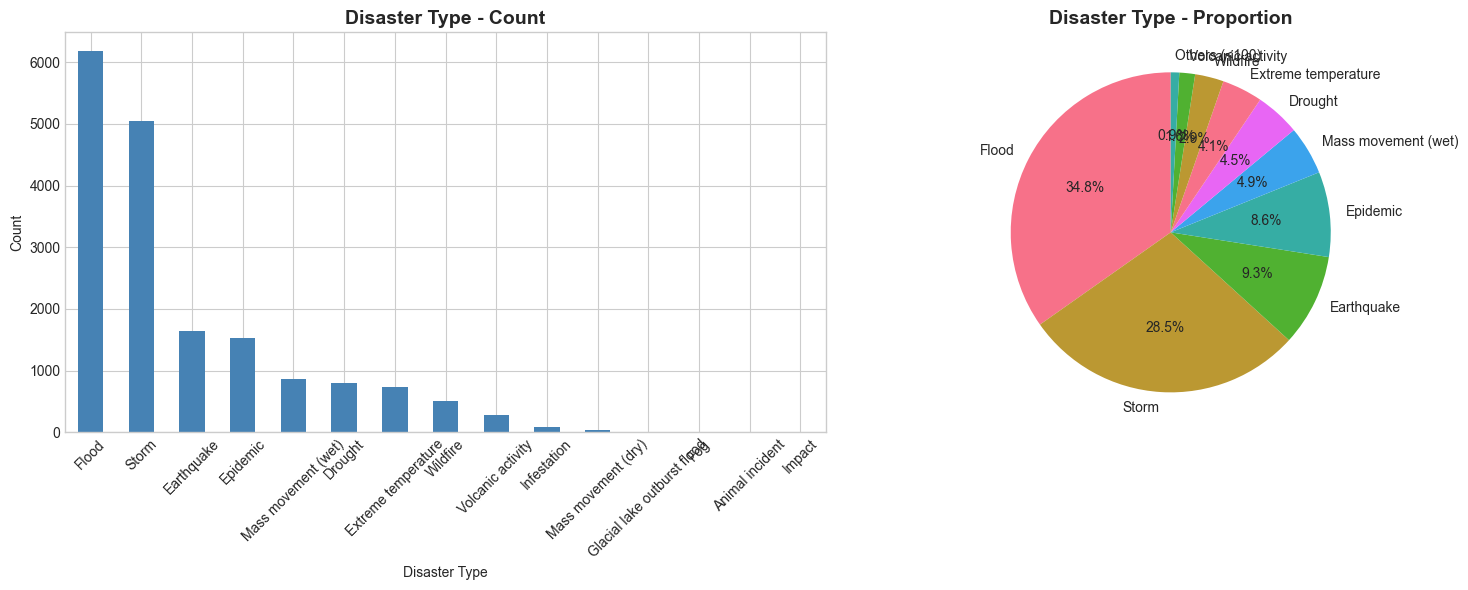

In [79]:
# Visualization - Disaster Type distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Count plot
df['Disaster Type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Disaster Type - Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Disaster Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Percentage pie (top classes + others)
top_types = df['Disaster Type'].value_counts()
others = top_types[top_types < 100].sum()
top_types_clean = top_types[top_types >= 100].copy()
top_types_clean['Others (<100)'] = others

axes[1].pie(top_types_clean, labels=top_types_clean.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Disaster Type - Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### คำถามให้คิด (ตอบใน markdown cell ถัดไปได้):

1. **Target ควรเป็นอะไร?**  
   - Disaster Group → มีแค่ 1 class (Natural) ใช้ไม่ได้
   - Disaster Subgroup → 6 classes (แต่ Extra-terrestrial มี 1 แถว)
   - Disaster Type → 15 classes (หลาย class มีน้อยมาก)
   - Disaster Subtype → เยอะเกินไป

2. **ควร group class ไหม?**  
   ดูไฟล์ `class_grouping.txt` ที่มีอยู่แล้ว

3. **Class imbalance รุนแรงแค่ไหน?**  
   Flood + Storm รวมกันเกือบ 63% ของข้อมูล

In [80]:
# ดู class_grouping ที่มีอยู่
with open('class_grouping.txt', 'r') as f:
    print(f.read())

# Class Grouping
Flood-related disasters → Flood
Flood
Glacial lake outburst flood

Landslide-related disasters → Landslide
Mass movement (dry)
Mass movement (wet)

Earth-related disasters → Earthquake
Earthquake
Impact

Disease-related disasters → Epidemic
Epidemic
Infestation
Animal incident

Temperature-related disasters → Extreme temperature
Extreme temperature
Fog

Others remain the same:
Storm
Drought
Wildfire
Volcanic activity


## 1.4 Missing Values Overview

In [81]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print('=== Missing Values (เรียงจากมากไปน้อย) ===')
print(missing_df[missing_df['Missing Count'] > 0])

=== Missing Values (เรียงจากมากไปน้อย) ===
                                           Missing Count  Missing %
Reconstruction Costs ('000 US$)                    17715      99.77
Reconstruction Costs, Adjusted ('000 US$)          17716      99.77
AID Contribution ('000 US$)                        16981      95.64
Insured Damage, Adjusted ('000 US$)                16619      93.60
Insured Damage ('000 US$)                          16609      93.54
River Basin                                        16154      90.98
No. Homeless                                       15213      85.68
Longitude                                          14923      84.04
Latitude                                           14923      84.04
Associated Types                                   13488      75.96
Event Name                                         13437      75.68
External IDs                                       13162      74.13
No. Injured                                        13102      73.79
Origi

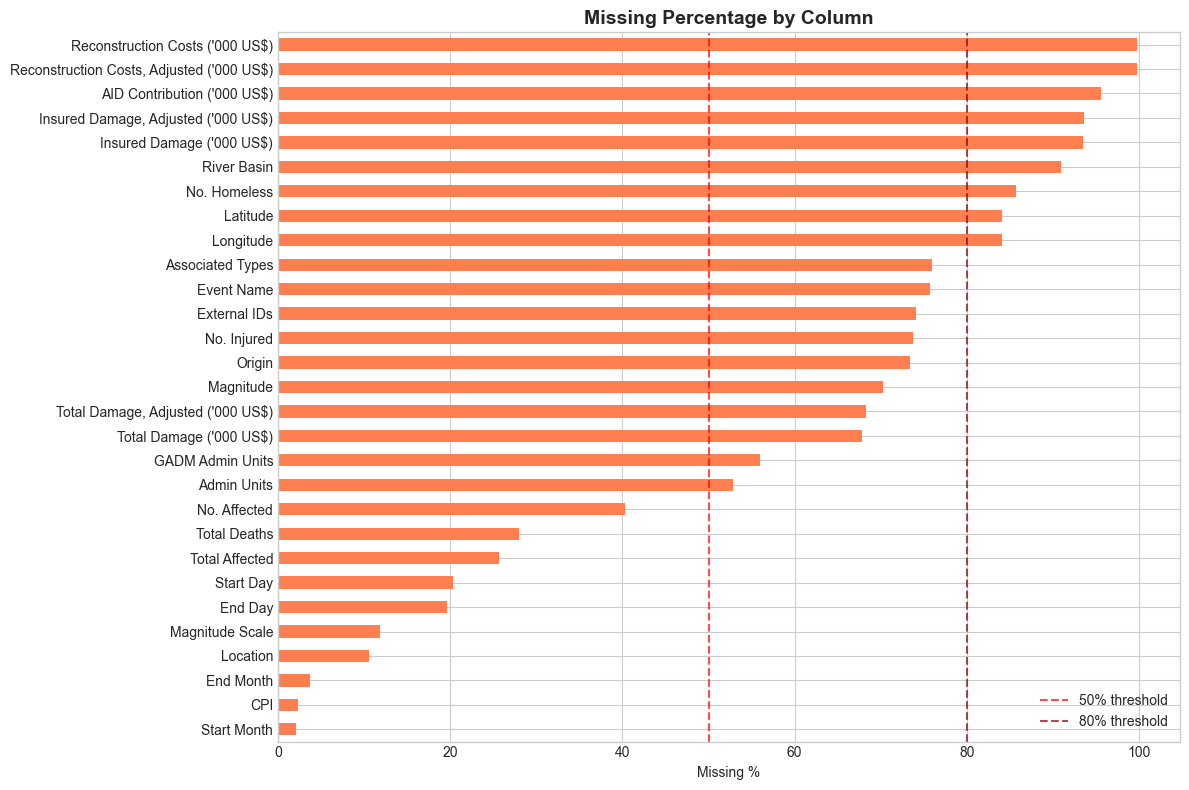

In [82]:
# Visualize missing
plt.figure(figsize=(12, 8))
missing_pct[missing_pct > 0].sort_values(ascending=True).plot(kind='barh', color='coral')
plt.title('Missing Percentage by Column', fontsize=14, fontweight='bold')
plt.xlabel('Missing %')
plt.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='50% threshold')
plt.axvline(x=80, color='darkred', linestyle='--', alpha=0.7, label='80% threshold')
plt.legend()
plt.tight_layout()
plt.show()

### Insight เบื้องต้นเกี่ยวกับ Missing:
- คอลัมน์ damage/cost ส่วนใหญ่ missing > 90% → น่าจะทิ้งหรือใช้เป็น binary (มี/ไม่มีข้อมูล)
- Latitude/Longitude missing ~84% → ใช้ยาก ถ้าจะใช้ต้องมี strategy
- Impact columns (Deaths, Affected...) missing 25-85% → อาจเป็น signal ที่ดี แต่ต้องระวัง leakage ถ้า target เกี่ยวกับความรุนแรง

## 1.5 ดู Unique values และ Cardinality

In [83]:
print('=== Number of unique values per column ===')
nunique = df.nunique().sort_values(ascending=False)
print(nunique)

=== Number of unique values per column ===
DisNo.                                       17756
Location                                     14303
Admin Units                                   6884
GADM Admin Units                              6434
Total Affected                                5831
Total Damage, Adjusted ('000 US$)             4246
No. Affected                                  4104
External IDs                                  3378
Longitude                                     2494
Entry Date                                    2452
Latitude                                      2421
Magnitude                                     1920
Event Name                                    1793
Total Damage ('000 US$)                       1633
River Basin                                   1514
No. Homeless                                   963
Total Deaths                                   936
Insured Damage, Adjusted ('000 US$)            889
No. Injured                            

In [84]:
# ดู categorical columns ที่มี cardinality ไม่สูงเกินไป
cat_cols = df.select_dtypes(include=['object', 'string']).columns
print('=== Categorical columns (unique < 50) ===')
for col in cat_cols:
    n = df[col].nunique()
    if n < 50:
        print(f'\n{col} ({n} unique):')
        print(df[col].value_counts().head(10))

=== Categorical columns (unique < 50) ===

Historic (2 unique):
Historic
No     10708
Yes     7048
Name: count, dtype: int64

Disaster Group (1 unique):
Disaster Group
Natural    17756
Name: count, dtype: int64

Disaster Subgroup (6 unique):
Disaster Subgroup
Hydrological         7047
Meteorological       5783
Geophysical          1978
Biological           1622
Climatological       1325
Extra-terrestrial       1
Name: count, dtype: int64

Disaster Type (15 unique):
Disaster Type
Flood                  6175
Storm                  5053
Earthquake             1650
Epidemic               1526
Mass movement (wet)     872
Drought                 803
Extreme temperature     729
Wildfire                514
Volcanic activity       282
Infestation              95
Name: count, dtype: int64

Subregion (17 unique):
Subregion
Latin America and the Caribbean    3051
Sub-Saharan Africa                 2926
Southern Asia                      2246
South-eastern Asia                 2209
Eastern Asia    

## 1.6 สรุปเบื้องต้น + การตัดสินใจ (คุณต้องกรอกส่วนนี้)

### สิ่งที่พบ:
- จำนวนข้อมูล: 17,756 แถว
- Target ที่แนะนำ: **Disaster Type** (หรือ version ที่ group แล้ว)
- Class imbalance: สูงมาก (Flood + Storm ≈ 63%)
- Missing: หลายคอลัมน์สูงมาก โดยเฉพาะ damage-related

### การตัดสินใจที่ต้องทำตอนนี้:
1. **Target สุดท้าย** จะเป็นอะไร? (แนะนำ: Disaster Type ที่ group ตาม `class_grouping.txt`)
2. **คอลัมน์ที่จะทิ้งทันที** (เช่น identifier, หรือ missing > 95%)
3. **คอลัมน์ที่น่าสนใจสำหรับ Feature Engineering**

---

**ตอนนี้ให้คุณตอบคำถามเหล่านี้ก่อนไปขั้นถัดไป:**

1. คุณอยากใช้ Target เป็น `Disaster Type` แบบเดิม หรือ group ตามไฟล์ `class_grouping.txt`?
2. มีคอลัมน์ไหนที่คุณคิดว่าควรทิ้งตั้งแต่ตอนนี้?
3. มี insight หรือข้อสงสัยอะไรจากข้อมูลที่เห็นไหม?

ตอบมาได้เลย แล้วเราจะไปขั้น EDA ต่อ

## 1.7 สร้าง Target ใหม่ตาม Class Grouping

ตามที่คุณตัดสินใจ: ใช้ grouping จาก `class_grouping.txt`

In [85]:
#  mapping by class_grouping.txt
grouping_map = {
    # Flood-related
    'Flood': 'Flood',
    'Glacial lake outburst flood': 'Flood',
    
    # Landslide-related
    'Mass movement (wet)': 'Landslide',
    'Mass movement (dry)': 'Landslide',
    
    # Earth-related
    'Earthquake': 'Earthquake',
    'Impact': 'Earthquake',
    
    # Disease-related
    'Epidemic': 'Epidemic',
    'Infestation': 'Epidemic',
    'Animal incident': 'Epidemic',
    
    # Temperature-related
    'Extreme temperature': 'Extreme temperature',
    'Fog': 'Extreme temperature',
    
    # เหลือตามเดิม
    'Storm': 'Storm',
    'Drought': 'Drought',
    'Wildfire': 'Wildfire',
    'Volcanic activity': 'Volcanic activity',
}

df['Target'] = df['Disaster Type'].map(grouping_map)

print('=== Target Grouping ===')
print(df['Target'].value_counts())
print()
print('=== Percentage ===')
print((df['Target'].value_counts(normalize=True) * 100).round(2))
print()
print(f'จำนวน class ใหม่: {df["Target"].nunique()}')
print(f'มีค่า NaN ใน Target ไหม?: {df["Target"].isna().sum()}')

=== Target Grouping ===
Target
Flood                  6183
Storm                  5053
Earthquake             1651
Epidemic               1622
Landslide               918
Drought                 803
Extreme temperature     730
Wildfire                514
Volcanic activity       282
Name: count, dtype: int64

=== Percentage ===
Target
Flood                  34.82
Storm                  28.46
Earthquake              9.30
Epidemic                9.13
Landslide               5.17
Drought                 4.52
Extreme temperature     4.11
Wildfire                2.89
Volcanic activity       1.59
Name: proportion, dtype: float64

จำนวน class ใหม่: 9
มีค่า NaN ใน Target ไหม?: 0


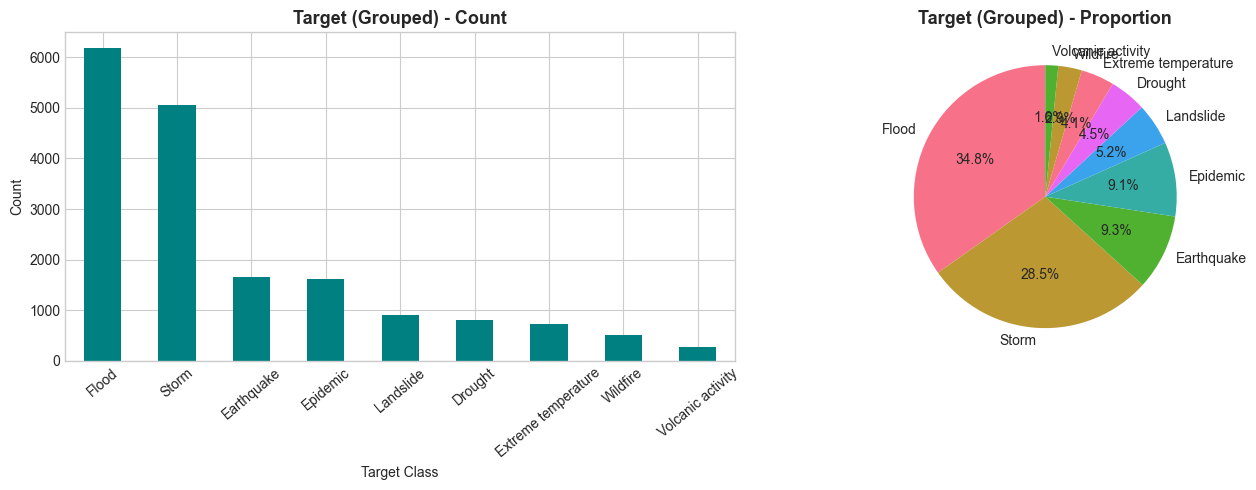

In [86]:
# Visualization Target ใหม่
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Target'].value_counts().plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Target (Grouped) - Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Target Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=40)

df['Target'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Target (Grouped) - Proportion', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### สังเกตหลัง Grouping
- Class ลดลงจาก 15 → 9 classes
- Flood และ Storm ยังคงเป็น majority ชัดเจน
- Class ที่น้อยที่สุดตอนนี้คือ Volcanic activity

**คำถามให้คิด:** Imbalance ยังสูงอยู่ไหม? เราควรใช้เทคนิคอะไรในขั้น modeling ภายหลัง?

## 1.8 ตัดสินใจคอลัมน์ที่จะทิ้งทันที (Drop Candidates)

หลักการ:
1. **Identifier / ไม่มี predictive power** → ทิ้ง
2. **Missing สูงมาก (>90-95%) และยากจะ impute อย่างมีความหมาย** → ทิ้ง หรือแปลงเป็น binary
3. **Leakage สูง** (บอก target เกือบตรง ๆ) → ทิ้ง
4. **High cardinality ที่ไม่เป็นประโยชน์** → พิจารณาทิ้งหรือลดมิติ

In [87]:
# --------------------------------------------------
# ลิสต์คอลัมน์ที่แนะนำให้ทิ้งทันที
# --------------------------------------------------

cols_to_drop_identifier = [
    'DisNo.',
    'Classification Key',      # มีโอกาส leakage สูง
    'External IDs',
    'Event Name',
]

cols_to_drop_high_missing = [
    "Reconstruction Costs ('000 US$)",
    "Reconstruction Costs, Adjusted ('000 US$)",
    "AID Contribution ('000 US$)",
    "Insured Damage ('000 US$)",
    "Insured Damage, Adjusted ('000 US$)",
]

# คอลัมน์ที่อาจมี leakage หรือซ้ำกับ target
cols_potential_leakage = [
    'Disaster Group',          # มีค่าเดียว
    'Disaster Subgroup',       # ใกล้เคียง target มาก
    'Disaster Type',           # เราใช้สร้าง Target แล้ว
    'Disaster Subtype',        # ใกล้เคียง target มาก
]

print('=== คอลัมน์ Identifier ที่แนะนำทิ้ง ===')
print(cols_to_drop_identifier)
print()
print('=== คอลัมน์ Missing สูงมากที่แนะนำทิ้ง ===')
print(cols_to_drop_high_missing)
print()
print('=== คอลัมน์ที่อาจ Leakage (ควรทิ้งหรือใช้อย่างระวัง) ===')
print(cols_potential_leakage)

=== คอลัมน์ Identifier ที่แนะนำทิ้ง ===
['DisNo.', 'Classification Key', 'External IDs', 'Event Name']

=== คอลัมน์ Missing สูงมากที่แนะนำทิ้ง ===
["Reconstruction Costs ('000 US$)", "Reconstruction Costs, Adjusted ('000 US$)", "AID Contribution ('000 US$)", "Insured Damage ('000 US$)", "Insured Damage, Adjusted ('000 US$)"]

=== คอลัมน์ที่อาจ Leakage (ควรทิ้งหรือใช้อย่างระวัง) ===
['Disaster Group', 'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype']


In [88]:
# รวมคอลัมน์ที่จะทิ้ง
cols_to_drop = cols_to_drop_identifier + cols_to_drop_high_missing + cols_potential_leakage

# ตรวจสอบว่ามีคอลัมน์เหล่านี้อยู่จริง
existing_drop = [c for c in cols_to_drop if c in df.columns]
missing_in_list = [c for c in cols_to_drop if c not in df.columns]

print(f'จำนวนคอลัมน์ที่จะทิ้ง: {len(existing_drop)}')
print('คอลัมน์ที่จะทิ้ง:', existing_drop)
if missing_in_list:
    print('คอลัมน์ที่ไม่มีในข้อมูล:', missing_in_list)

จำนวนคอลัมน์ที่จะทิ้ง: 13
คอลัมน์ที่จะทิ้ง: ['DisNo.', 'Classification Key', 'External IDs', 'Event Name', "Reconstruction Costs ('000 US$)", "Reconstruction Costs, Adjusted ('000 US$)", "AID Contribution ('000 US$)", "Insured Damage ('000 US$)", "Insured Damage, Adjusted ('000 US$)", 'Disaster Group', 'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype']


In [89]:
# สร้าง dataframe ใหม่หลัง drop (ยังไม่บันทึกถาวร)
df_clean = df.drop(columns=existing_drop)

print(f'Shape เดิม: {df.shape}')
print(f'Shape หลัง drop: {df_clean.shape}')
print()
print('คอลัมน์ที่เหลือ:')
print(df_clean.columns.tolist())

Shape เดิม: (17756, 48)
Shape หลัง drop: (17756, 35)

คอลัมน์ที่เหลือ:
['Historic', 'ISO', 'Country', 'Subregion', 'Region', 'Location', 'Origin', 'Associated Types', 'OFDA/BHA Response', 'Appeal', 'Declaration', 'Magnitude', 'Magnitude Scale', 'Latitude', 'Longitude', 'River Basin', 'Start Year', 'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day', 'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless', 'Total Affected', "Total Damage ('000 US$)", "Total Damage, Adjusted ('000 US$)", 'CPI', 'Admin Units', 'GADM Admin Units', 'Entry Date', 'Last Update', 'Target']


### สรุปการตัดสินใจในขั้น Data Understanding

| หัวข้อ | การตัดสินใจ |
|--------|-------------|
| **Target** | `Target` ที่ group แล้ว (9 classes) |
| **ทิ้งทันที** | Identifier + High missing damage + Disaster* columns |
| **เก็บไว้พิจารณาต่อ** | Location, Time, Impact (Deaths/Affected), Magnitude, Origin, ฯลฯ |

---

**คำถามก่อนไปขั้น EDA:**
1. คุณเห็นด้วยกับลิสต์คอลัมน์ที่ทิ้งไหม? มีตัวไหนอยากเก็บไว้หรืออยากทิ้งเพิ่มไหม?
2. `Latitude` / `Longitude` (missing ~84%) อยากเก็บไว้ลองใช้ใน EDA ไหม?
3. พร้อมไปขั้น **02_EDA** แล้วหรือยัง?

ตอบมาได้เลย แล้วเราจะเริ่มทำ EDA ต่อ